<a href="https://colab.research.google.com/github/lalin15rv-bit/Inteligencia-Artificial/blob/main/CNN/clasificaci%C3%B3n_de_ropa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf                     #importamos todas nuestras librerias que vamos a necesitar
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Softmax           #Son operaciones nú,ericas en las cuales nos ayuda a
from tensorflow.keras.optimizers import Adam                                                #construir y entrenar las redes neuronales
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt                                                       #Nos ayuda visualizar los datos

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist         #acceder fácilmente a las imágenes y etiquetas del conjunto de datos

In [ ]:
fashion_mnist.load_data         #Nos muestra la informaciíon

<function keras.src.datasets.fashion_mnist.load_data()>

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']         #Contiene los nombres de las 10 categorías diferentes de prendas de vestir

In [ ]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
index = 1212        #Damos la cantidad que nos hace mostrar diferentes estilos de ropa

In [ ]:
image = train_images[index]
label = train_labels[index]         #Selecciona una imagen y su etiqueta correspondiente del conjunto de datos de entrenamiento

In [ ]:
print(image)      #Imprime la imagen en forma de una matriz

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  1

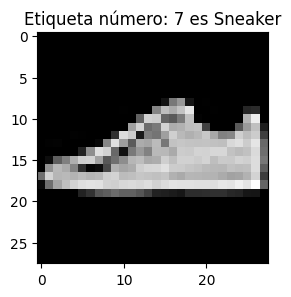

In [ ]:
plt.figure(figsize=(3, 3))          #Tamaño de la figura
plt.imshow(image, cmap=plt.cm.gray)         #muestra la imagen
plt.title(f'Etiqueta número: {label} es {class_names[label]}')          #Nombre o etiqueta de la imagen
plt.show()            #Imprime lo pedido

In [ ]:
print(train_images.shape)         #Imprime la dimension de los conjuntos de datos
print(test_images.shape)          #Regresa una tupla que representa forma y tamaño

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
# Normalizar las imágenes para que los valores estén en el rango [0, 1]
train_images = train_images / 255.0           #Valor de las imagenes en pixeles y estan en rango de 0 al 255
test_images = test_images / 255.0

In [ ]:
# Crear el modelo de CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),            # imagen de 28x28 y el filtro será de 3x3
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),          #Segunda capa con 64 filtros y activa el relu
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),              #tercera capa
    Flatten(),
    Dense(64, activation='relu'),                                 #64 neuronas
    Dense(10)  # 10 neuronas porque son las que se clasifican
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Tasa de aprendizaje deseada
learning_rate = 0.001           #controla el tamaño de los pasos que toma el optimizador para ajustar los pesos del modelo
adam_optimizer = Adam(learning_rate=learning_rate)        #Optimiza y define los pesos del modelo

In [ ]:
model.compile(optimizer=adam_optimizer,
              loss=SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))        #Colocamos las epocas que queremos que aprenda

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - accuracy: 0.7516 - loss: 0.6898 - val_accuracy: 0.8711 - val_loss: 0.3455
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8814 - loss: 0.3248 - val_accuracy: 0.8885 - val_loss: 0.3152
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8984 - loss: 0.2738 - val_accuracy: 0.8930 - val_loss: 0.3074
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9102 - loss: 0.2458 - val_accuracy: 0.9055 - val_loss: 0.2654
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9189 - loss: 0.2167 - val_accuracy: 0.9062 - val_loss: 0.2603
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9272 - loss: 0.1978 - val_accuracy: 0.9031 - val_loss: 0.2700
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9362 - loss: 0.1748 - val_accuracy: 0.9070 - val_loss: 0.2633
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9377 -

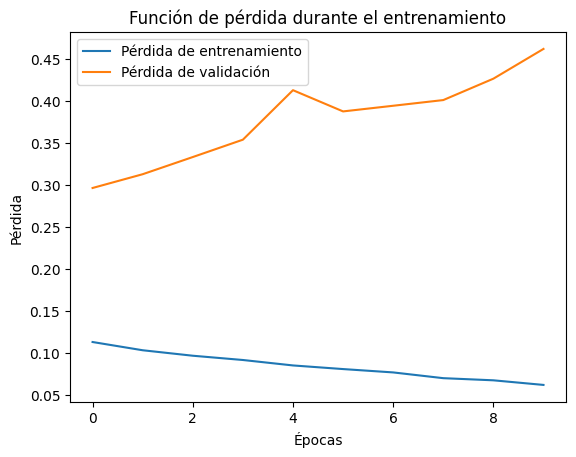

In [ ]:
import matplotlib.pyplot as plt       #Libreria para ayudarnos a graficar

plt.plot(history.history['loss'], label='Pérdida de entrenamiento')         #Muestra indicador de la linea 'Pérdida de entrenamiento'
plt.plot(history.history['val_loss'], label='Pérdida de validación')         #Muestra indicador de la linea 'Pérdida de validación'
plt.xlabel('Épocas')         #Nombre del eje y
plt.ylabel('Pérdida')         #Nombre del eje X
plt.legend()
plt.title('Función de pérdida durante el entrenamiento')        #titulo de la gráfica
plt.show()


In [ ]:
# Evaluar el modelo
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)         #calcula la perdida y la prescisión

313/313 - 3s - 9ms/step - accuracy: 0.9086 - loss: 0.4622


In [ ]:
probability_model = Sequential([model, Softmax()])                #Se utiliza para encontrar el índice de la probabilidad
predictions = probability_model.predict(test_images)              #más alta para cada predicción, lo que nos da la etiqueta de la clase
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [ ]:
# Calcular matriz de confusión
cm = confusion_matrix(test_labels, predicted_labels)              # Nos describe el rendimiento de un modelo de clasificación en un conjunto de datos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)        #Asegurar que la matriz se muestre con etiquetas claras y fáciles de entender

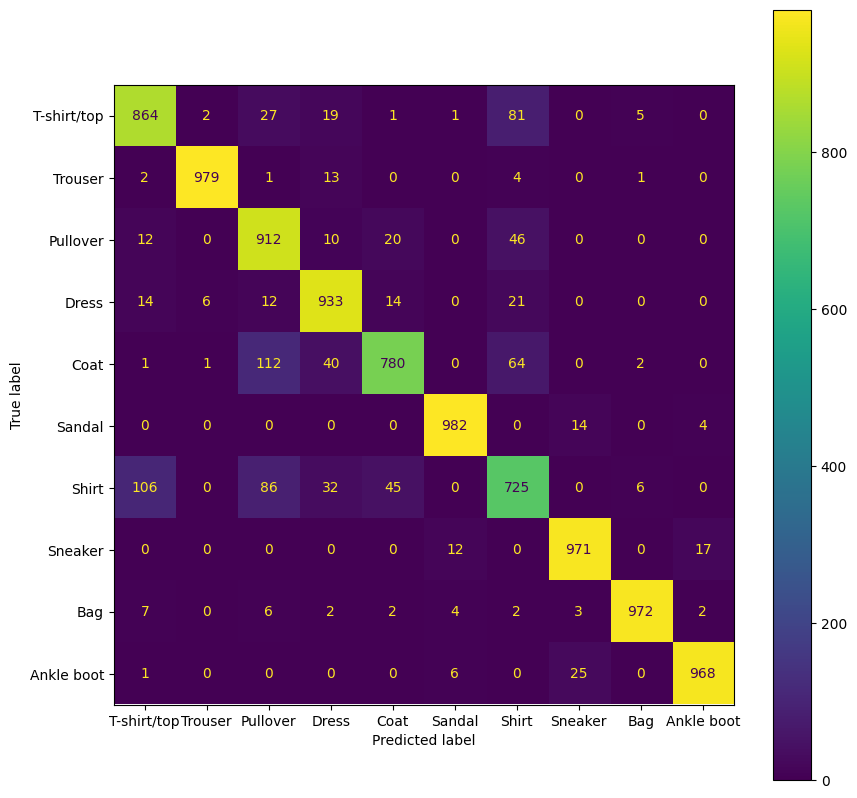

In [ ]:
# Graficar matriz de confusión
fig, ax = plt.subplots(figsize=(10, 10))        #Tamaño de nuestra tabla
disp.plot(ax=ax)            #Agarra el objeto  que ya contiene la matriz
plt.show()                  #Mostrar nuestra tabla

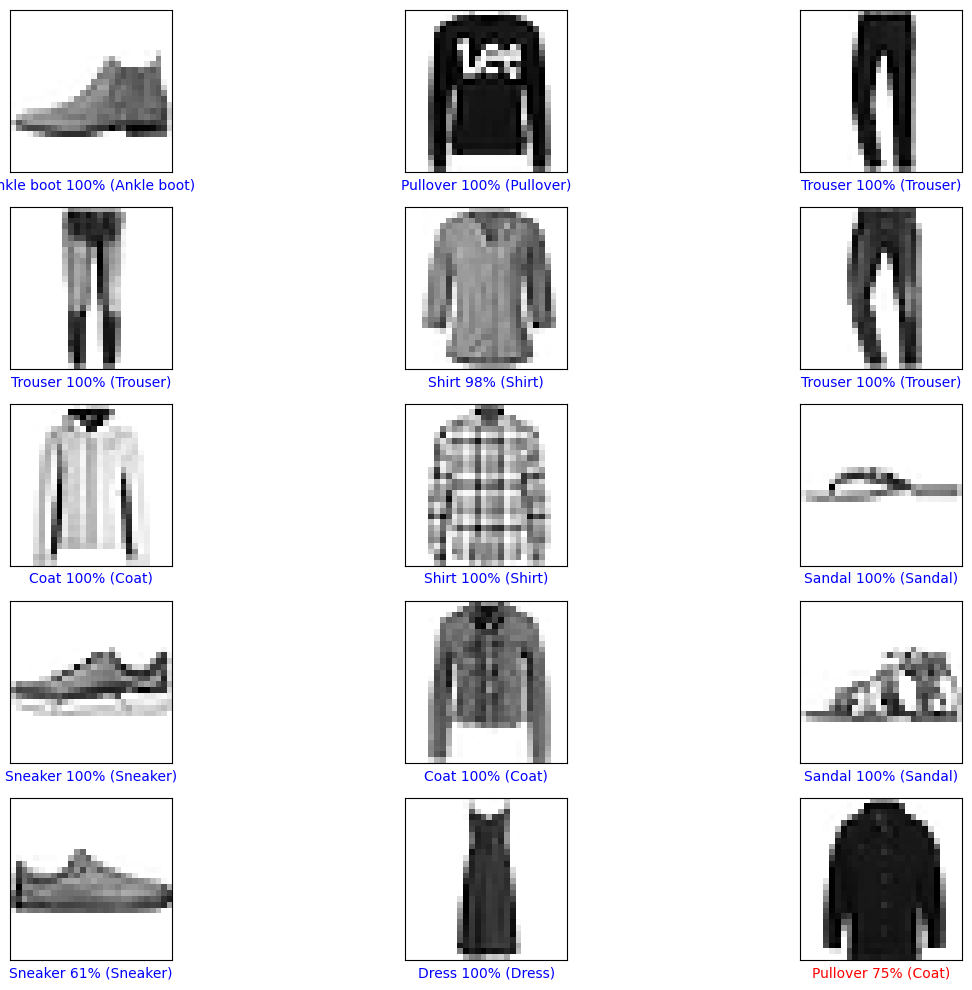

In [ ]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]             #Muestra una imagen en específico
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img.reshape((28, 28)), cmap=plt.cm.binary)

    predicted_label = tf.argmax(predictions_array).numpy()
    if predicted_label == true_label:
        color = 'blue'              #Color del título en caso que tenga una buena predicción
    else:
        color = 'red'                #Color del título en caso que tenga una baja predicción

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*tf.reduce_max(predictions_array).numpy(),
                                         class_names[true_label]),
                                         color=color)

# Graficar algunas predicciones
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']       #Etiquetas de las qimagenes que queremos que salgan

num_rows = 5        #Numero de imágenes que salen en 5 filas
num_cols = 3        #Numero de imágenes que salen en 3 columnas
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)       #Muestra de cada imagen, contenido, predicción y si fue correcta o incorrecta

plt.tight_layout()
plt.show()                  #Muestra lo pedido